In [2]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_md = pd.read_csv("./MIQR-CC-Dataset/metadata.csv")
df_md

,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard
...,...,...,...,...,...,...,...,...,...,...,...,...
19312,raw/1601_image19016.png,processed/1601_image19016_section_1.png,1601,V,M,20/02/1928,15/02/2018,12:05:41,89.0,PCR Eleva,Unlabelled,Keep
19313,raw/1601_image19016.png,processed/1601_image19016_section_2.png,1601,V,M,20/02/1928,15/02/2018,12:05:41,89.0,PCR Eleva,Unlabelled,Keep
19314,raw/1601_image19017.png,processed/1601_image19017_section_1.png,1601,V,M,20/02/1928,15/02/2018,12:07:21,89.0,PCR Eleva,Unlabelled,Keep
19315,raw/1602_image19018.png,processed/1602_image19018_section_1.png,1602,V,F,10/06/1939,25/07/2019,12:45:02,80.0,PCR Eleva,Unlabelled,Keep


In [11]:
df_md.Keep.value_counts(dropna=False)

Keep
Keep       15216
Discard     4101
Name: count, dtype: int64

In [10]:
df_md.Label.value_counts(dropna=False)

Label
Unlabelled             13798
Lithiasis               2651
Malignant Stricture     1281
Normal                  1012
Biliary Leaks            361
Benign Stricture         214
Name: count, dtype: int64

In [18]:
df = df_md[(df_md.Label != 'Unlabelled') & (df_md.Keep == 'Keep')].drop_duplicates('raw_image_path')
df.Label.value_counts(dropna=False)

Label
Lithiasis              722
Malignant Stricture    328
Normal                 291
Biliary Leaks          149
Benign Stricture        63
Name: count, dtype: int64

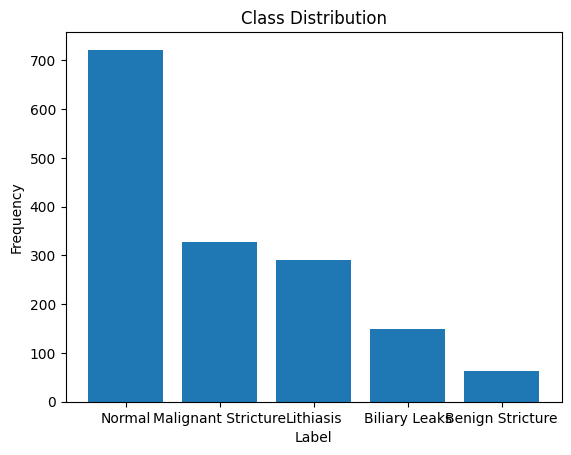

In [5]:
plt.bar(df.Label.unique(), df.Label.value_counts())
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

In [6]:
# Há 1.571 pacientes no total ao invés dos 1.602 descritos no artigo
df_md_patients = df_md[['patient_id', 'sex', 'birth_date', 'age']]
df_md_patients.drop_duplicates(['patient_id'], inplace=True)
print(df_md_patients.shape)
df_md_patients['sex'].value_counts(dropna=False)

(1571, 4)


sex
F    791
M    780
Name: count, dtype: int64

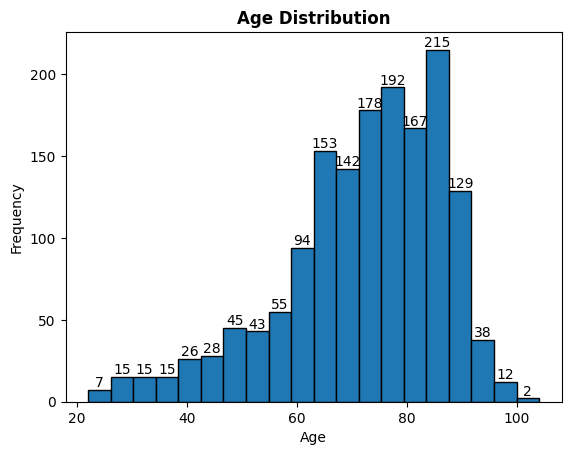

In [7]:
counts, bins, patches = plt.hist(df_md_patients['age'], 20, edgecolor='black')

plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution', fontweight='bold')

plt.show()

In [8]:
# Há 436 pacientes de imagens válidas
df_md_patients = df_md[(df_md.Label != 'Unlabelled') & (df_md.Keep == 'Keep')][['patient_id', 'sex', 'birth_date', 'age']]
print(df_md_patients.shape)
df_md_patients.drop_duplicates(['patient_id'], inplace=True)
print(df_md_patients.shape)
df_md_patients['sex'].value_counts(dropna=False)

(1568, 4)
(436, 4)


sex
F    228
M    208
Name: count, dtype: int64

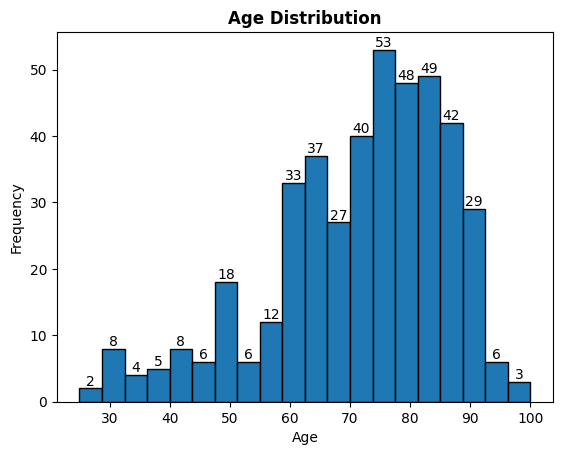

In [9]:
counts, bins, patches = plt.hist(df_md_patients['age'], 20, edgecolor='black')

plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution', fontweight='bold')

plt.show()

whiskers: [array([63., 33.]), array([ 83., 100.])]
caps: [array([33., 33.]), array([100., 100.])]
boxes: [array([63., 63., 83., 83., 63.])]
medians: [array([74., 74.])]
fliers: [array([31., 32., 25., 31., 26., 32., 29., 30., 32., 29.])]
means: []


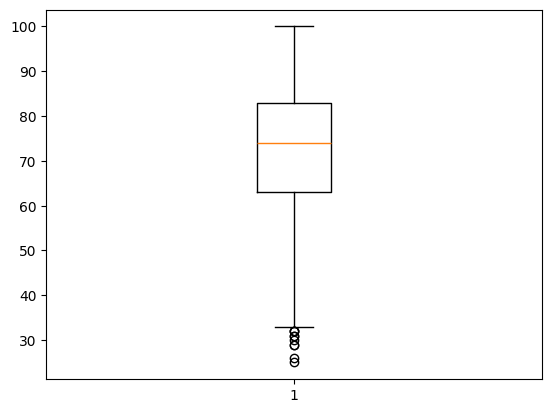

In [27]:
box = plt.boxplot(df_md_patients['age'])
for feature, values in box.items():
    print(f'{feature}: {[item.get_ydata() for item in values]}')
plt.show()